In [1]:
import yfinance as yf
import pandas as pd

# Mastercard Incorporated Common Stock (MA)

## Collecting data

In [2]:
# Ticker
ticker = "MA"

# Create a Ticker object
ma = yf.Ticker(ticker)

In [7]:
'''Date:  from 2025-01-02 to 2025-07-01'''
'''Interval: daily data'''
data_ma = ma.history(start="2025-01-02", end="2025-07-01", interval="1d")

## Descriptive statistics

In [8]:
print(data_ma.head())

                                 Open        High         Low       Close  \
Date                                                                        
2025-01-02 00:00:00-05:00  524.476385  525.834178  513.049057  517.746887   
2025-01-03 00:00:00-05:00  517.875748  519.788549  513.068911  516.716125   
2025-01-06 00:00:00-05:00  516.329605  516.716146  506.458359  507.370148   
2025-01-07 00:00:00-05:00  509.104570  511.730990  506.527722  506.844879   
2025-01-08 00:00:00-05:00  507.479143  512.840989  506.973707  511.800354   

                            Volume  Dividends  Stock Splits  
Date                                                         
2025-01-02 00:00:00-05:00  2818800        0.0           0.0  
2025-01-03 00:00:00-05:00  1627500        0.0           0.0  
2025-01-06 00:00:00-05:00  2920800        0.0           0.0  
2025-01-07 00:00:00-05:00  2211800        0.0           0.0  
2025-01-08 00:00:00-05:00  2456700        0.0           0.0  


### Extract only the opening and closing price columns

In [9]:
# Extract only the opening and closing price columns
open_prices = data_ma["Open"]
close_prices = data_ma["Close"]

ma_open_close = pd.DataFrame({"Date": open_prices.index, "Open": open_prices.values, "Close": close_prices.values})
ma_open_close.reset_index(drop=True, inplace=True)
print(ma_open_close.head())

                       Date        Open       Close
0 2025-01-02 00:00:00-05:00  524.476385  517.746887
1 2025-01-03 00:00:00-05:00  517.875748  516.716125
2 2025-01-06 00:00:00-05:00  516.329605  507.370148
3 2025-01-07 00:00:00-05:00  509.104570  506.844879
4 2025-01-08 00:00:00-05:00  507.479143  511.800354


### Extract only the closing price columns

In [10]:
# Extract only the closing price column
close_prices = data_ma["Close"]

ma_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
ma_close.reset_index(drop=True, inplace=True)

print(ma_close.head())

                       Date       Close
0 2025-01-02 00:00:00-05:00  517.746887
1 2025-01-03 00:00:00-05:00  516.716125
2 2025-01-06 00:00:00-05:00  507.370148
3 2025-01-07 00:00:00-05:00  506.844879
4 2025-01-08 00:00:00-05:00  511.800354


In [11]:
data_ma.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,122.000000,122.000000,122.000000,122.000000,1.220000e+02,122.000000,122.0
mean,544.450482,550.047365,539.273691,545.061638,2.877898e+06,0.012459,0.0
std,25.267906,23.577414,26.556301,25.218668,1.183384e+06,0.096905,0.0
min,467.349494,498.460450,462.123046,476.346344,1.347800e+06,0.000000,0.0
25%,525.829008,530.795286,522.385764,526.673859,2.131600e+06,0.000000,0.0
50%,547.617786,554.815543,542.388474,546.098999,2.573800e+06,0.000000,0.0
75%,563.434712,567.886586,559.684162,562.987473,3.154275e+06,0.000000,0.0
max,586.853540,591.217776,584.149481,587.271057,8.202800e+06,0.760000,0.0


In [12]:
data_ma.shape

(122, 7)

In [13]:
data_ma.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 122 entries, 2025-01-02 00:00:00-05:00 to 2025-06-30 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          122 non-null    float64
 1   High          122 non-null    float64
 2   Low           122 non-null    float64
 3   Close         122 non-null    float64
 4   Volume        122 non-null    int64  
 5   Dividends     122 non-null    float64
 6   Stock Splits  122 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 7.6 KB


In [14]:
data_ma.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

## KPIs

### Completeness

In [15]:
missing_values_count = data_ma.isnull().sum()

print("Missing values per column:")
print(missing_values_count)

Missing values per column:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


In [16]:
'''1.2 Pecetange of the Missing Values'''

total_rows = len(data_ma)

missing_info = pd.DataFrame({
    'missing_count': data_ma.isnull().sum(),
    'missing_percentage': (data_ma.isnull().sum() / total_rows) * 100
})

print(missing_info)

              missing_count  missing_percentage
Open                      0                 0.0
High                      0                 0.0
Low                       0                 0.0
Close                     0                 0.0
Volume                    0                 0.0
Dividends                 0                 0.0
Stock Splits              0                 0.0


### Latency

In [17]:
'''2.1 minimum and Maxmimum Close Price'''
min_close = data_ma['Close'].min()
max_close = data_ma['Close'].max()
print(f"Minimum Close Price: {min_close}")
print(f"Maximum Close Price: {max_close}")
print(f"Difference between Max and Min Close Price: {max_close - min_close}")

Minimum Close Price: 476.3463439941406
Maximum Close Price: 587.2710571289062
Difference between Max and Min Close Price: 110.92471313476562


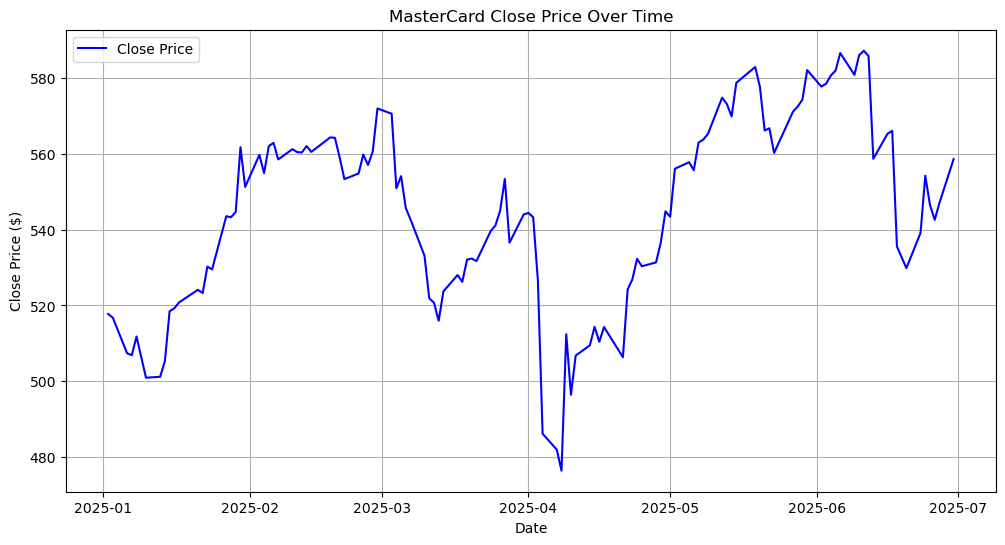

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
# Convert 'Date' column to datetime
ma_close['Date'] = pd.to_datetime(ma_close['Date'])


# Set 'Date' as the index 
ma_close.set_index('Date', inplace=True)


# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(ma_close.index, ma_close['Close'], color='blue', label='Close Price')
plt.title('MasterCard Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

### Consistency

In [19]:
print(data_ma.dtypes)

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


In [20]:
print(data_ma.apply(lambda x: x.map(type).nunique()))

Open            1
High            1
Low             1
Close           1
Volume          1
Dividends       1
Stock Splits    1
dtype: int64


### Error rate

In [21]:
# Missing rate
missing_rate = data_ma.isnull().mean() * 100
print(missing_rate)

Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
dtype: float64


In [22]:
# Duplicate rate
duplicate_rate = data_ma.duplicated().mean() * 100
print(duplicate_rate)

0.0


In [23]:
# Outliers
Q1 = data_ma['Close'].quantile(0.25)
Q3 = data_ma['Close'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data_ma['Close'] < Q1 - 1.5 * IQR) | (data_ma['Close'] > Q3 + 1.5 * IQR)).mean() * 100
print(outliers)

0.0


## ACCURACY

In [24]:
valid_close = data_ma['Close'] > 0
valid_volume = data_ma['Volume'] > 0
valid_dividends = data_ma['Dividends'] >= 0

accurate_records = data_ma[valid_close & valid_volume & valid_dividends]
data_accuracy_rate = (len(accurate_records) / len(data_ma)) * 100
print(f"✅ Data Accuracy Rate: {data_accuracy_rate:.2f}%")

✅ Data Accuracy Rate: 100.00%


In [25]:
invalid_records = data_ma[~(valid_close & valid_volume & valid_dividends)]
invalid_value_rate = (len(invalid_records) / len(data_ma)) * 100
print(f"❌ Invalid Value Rate: {invalid_value_rate:.2f}%")

❌ Invalid Value Rate: 0.00%


In [26]:
duplicate_rows = data_ma.duplicated()
duplicate_accuracy_rate = ((~duplicate_rows).sum() / len(data_ma)) * 100
print(f"📄 Duplicate Accuracy Rate: {duplicate_accuracy_rate:.2f}%")

📄 Duplicate Accuracy Rate: 100.00%


In [27]:
unit_price_accuracy = (data_ma['Close'] > 0).sum() / len(data_ma) * 100
print(f"💰 Close Price Field Accuracy Rate: {unit_price_accuracy:.2f}%")

💰 Close Price Field Accuracy Rate: 100.00%
